In [ ]:
#!/usr/bin/env python
# coding: utf-8



In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split 
from sklearn.pipeline import Pipeline 
from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import ( 
    confusion_matrix, 
    accuracy_score, 
    classification_report, 
    roc_curve, 
    roc_auc_score 
) 
# --------------------------------------------------------- 
# 1. LOAD AND CLEAN THE DATASET 
# --------------------------------------------------------- 
FILE_PATH = "diabetes.csv" 
df = pd.read_csv(FILE_PATH) 

# Remove empty/comment columns such as Unnamed: 9, Unnamed: 10, Unnamed: 11 
df = df.loc[:, ~df.columns.str.startswith("Unnamed")] 
print("\nFIRST FIVE RECORDS") 
print(df.head()) 
print("\nDATASET SHAPE") 
print(df.shape) 
print("\nCOLUMN NAMES") 
print(df.columns.tolist()) 
print("\nDATA TYPES AND NON-NULL COUNTS") 
df.info() 
print("\nMISSING VALUES") 
print(df.isnull().sum()) 
print("\nDUPLICATE ROWS:", df.duplicated().sum()) 
print("\nDESCRIPTIVE STATISTICS") 
print(df.describe().T) 
 





FIRST FIVE RECORDS
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

DATASET SHAPE
(768, 9)

COLUMN NAMES
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

DATA TYPES AND NON-NULL COUNTS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (to


AGE SUMMARY
         Statistic      Value
             Count 768.000000
              Mean  33.240885
Standard deviation  11.760232
           Minimum  21.000000
   25th percentile  24.000000
            Median  29.000000
   75th percentile  41.000000
           Maximum  81.000000

AGE FREQUENCY TABLE
 Age  Number of patients
  21                  63
  22                  72
  23                  38
  24                  46
  25                  48
  26                  33
  27                  32
  28                  35
  29                  29
  30                  21
  31                  24
  32                  16
  33                  17
  34                  14
  35                  10
  36                  16
  37                  19
  38                  16
  39                  12
  40                  13
  41                  22
  42                  18
  43                  13
  44                   8
  45                  15
  46                  13
  47                 

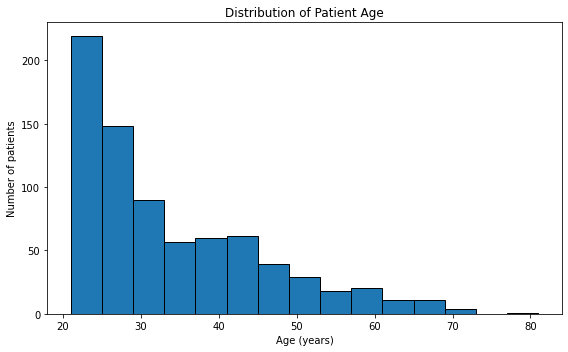

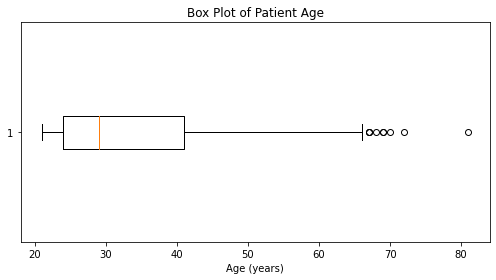

In [2]:
age_summary = pd.DataFrame({ 
    "Statistic": ["Count", "Mean", "Standard deviation", "Minimum", 
                  "25th percentile", "Median", "75th percentile", "Maximum"], 
    "Value": [ 
        df["Age"].count(), 
        df["Age"].mean(), 
        df["Age"].std(), 
        df["Age"].min(), 
        df["Age"].quantile(0.25), 
        df["Age"].median(), 
        df["Age"].quantile(0.75), 
        df["Age"].max() 
    ] 
}) 
  
print("\nAGE SUMMARY") 
print(age_summary.to_string(index=False)) 
  
age_frequency = df["Age"].value_counts().sort_index().rename_axis("Age").reset_index(name="Number of patients") 
print("\nAGE FREQUENCY TABLE") 
print(age_frequency.to_string(index=False)) 
  
plt.figure(figsize=(8, 5)) 
plt.hist(df["Age"], bins=15, edgecolor="black") 
plt.xlabel("Age (years)") 
plt.ylabel("Number of patients") 
plt.title("Distribution of Patient Age") 
plt.tight_layout() 
plt.savefig("age_histogram.png", dpi=200) 
plt.show() 
  
plt.figure(figsize=(7, 4)) 
plt.boxplot(df["Age"], vert=False) 
plt.xlabel("Age (years)") 
plt.title("Box Plot of Patient Age") 
plt.tight_layout() 
plt.savefig("age_boxplot.png", dpi=200) 
plt.show() 





AGE AND BMI WITH RESPECT TO CLASS
                  Number_of_patients  Mean_age  Std_age  Median_age  Mean_BMI  \
Outcome                                                                         
0 - Non-diabetic                 500     31.19    11.67        27.0     30.86   
1 - Diabetic                     268     37.07    10.97        36.0     35.41   

                  Std_BMI  Median_BMI  
Outcome                                
0 - Non-diabetic     6.56        30.1  
1 - Diabetic         6.61        34.3  


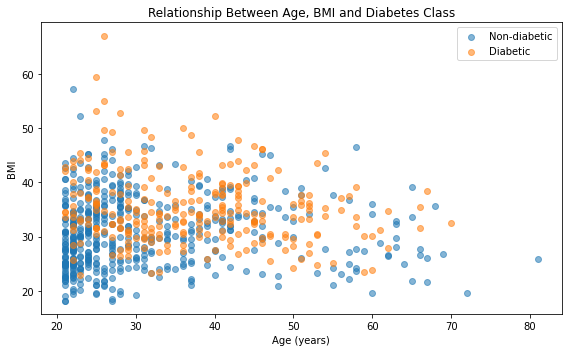

In [3]:
# --------------------------------------------------------- 
# 3. RELATIONSHIP OF AGE AND BMI WITH CLASS 
# --------------------------------------------------------- 
# BMI = 0 is physiologically invalid and represents a missing measurement. 
analysis_df = df.copy() 
analysis_df["BMI_valid"] = analysis_df["BMI"].replace(0, np.nan) 
  
relationship_table = analysis_df.groupby("Outcome").agg( 
    Number_of_patients=("Outcome", "size"), 
    Mean_age=("Age", "mean"), 
    Std_age=("Age", "std"), 
    Median_age=("Age", "median"), 
    Mean_BMI=("BMI_valid", "mean"), 
    Std_BMI=("BMI_valid", "std"), 
    Median_BMI=("BMI_valid", "median") 
).round(2) 
  
relationship_table.index = relationship_table.index.map({ 
    0: "0 - Non-diabetic", 
    1: "1 - Diabetic" 
}) 
  
print("\nAGE AND BMI WITH RESPECT TO CLASS") 
print(relationship_table) 
  
plt.figure(figsize=(8, 5)) 
for class_value, class_name in [(0, "Non-diabetic"), (1, "Diabetic")]: 
    subset = analysis_df[analysis_df["Outcome"] == class_value] 
    plt.scatter(subset["Age"], subset["BMI_valid"], alpha=0.55, label=class_name) 
plt.xlabel("Age (years)") 
plt.ylabel("BMI") 
plt.title("Relationship Between Age, BMI and Diabetes Class") 
plt.legend() 
plt.tight_layout() 
plt.savefig("age_bmi_by_class.png", dpi=200) 
plt.show() 





CLASS DISTRIBUTION
 Class label      Meaning  Count  Percentage
           0 Non-diabetic    500        65.1
           1     Diabetic    268        34.9


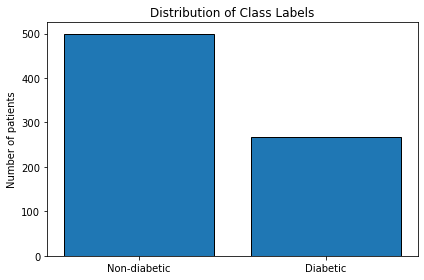

In [4]:
# --------------------------------------------------------- 
# 4. CLASS DISTRIBUTION 
# --------------------------------------------------------- 
class_table = pd.DataFrame({ 
    "Class label": [0, 1], 
    "Meaning": ["Non-diabetic", "Diabetic"], 
    "Count": [ 
        (df["Outcome"] == 0).sum(), 
        (df["Outcome"] == 1).sum() 
    ] 
}) 
class_table["Percentage"] = (class_table["Count"] / len(df) * 100).round(2) 
  
print("\nCLASS DISTRIBUTION") 
print(class_table.to_string(index=False)) 
  
plt.figure(figsize=(6, 4)) 
plt.bar(class_table["Meaning"], class_table["Count"], edgecolor="black") 
plt.ylabel("Number of patients") 
plt.title("Distribution of Class Labels") 
plt.tight_layout() 
plt.savefig("class_distribution.png", dpi=200) 
plt.show() 




In [5]:
# --------------------------------------------------------- 
# 5. LOGISTIC REGRESSION: 70% TRAINING, 30% TESTING 
# --------------------------------------------------------- 
X = df.drop(columns="Outcome").copy() 
y = df["Outcome"].copy() 
  
# In these columns, zero is an impossible measurement and is treated as missing. 
zero_as_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"] 
X[zero_as_missing] = X[zero_as_missing].replace(0, np.nan) 
  
X_train, X_test, y_train, y_test = train_test_split( 
    X, 
    y, 
    test_size=0.30, 
    random_state=42, 
    stratify=y 
) 
  
model = Pipeline(steps=[ 
    ("imputer", SimpleImputer(strategy="median")), 
    ("scaler", StandardScaler()), 
    ("classifier", LogisticRegression(max_iter=1000, random_state=42)) 
]) 
  
model.fit(X_train, y_train) 
  
y_pred = model.predict(X_test) 
y_probability = model.predict_proba(X_test)[:, 1] 
  
print("\nTRAINING SET SHAPE:", X_train.shape) 
print("TEST SET SHAPE:", X_test.shape) 
  
prediction_table = pd.DataFrame({ 
    "Actual class": y_test.to_numpy(), 
    "Predicted class": y_pred, 
    "Probability of diabetes": y_probability 
}) 
print("\nFIRST 15 TEST PREDICTIONS") 
print(prediction_table.head(15).round(4).to_string(index=False)) 
  





TRAINING SET SHAPE: (537, 8)
TEST SET SHAPE: (231, 8)

FIRST 15 TEST PREDICTIONS
 Actual class  Predicted class  Probability of diabetes
            1                0                   0.2405
            1                0                   0.2701
            1                1                   0.7763
            1                1                   0.6590
            1                1                   0.5061
            0                0                   0.0686
            0                1                   0.7145
            0                0                   0.1049
            0                0                   0.0399
            0                0                   0.3737
            0                0                   0.0522
            0                0                   0.0786
            0                0                   0.0580
            0                0                   0.4706
            1                1                   0.8369



CONFUSION MATRIX
[[129  21]
 [ 38  43]]

CONFUSION MATRIX VALUES
True Negative  (TN): 129
False Positive (FP): 21
False Negative (FN): 38
True Positive  (TP): 43

PERFORMANCE TABLE
                                Measure    Value  Percentage
                               Accuracy 0.744589       74.46
True positive rate (Sensitivity/Recall) 0.530864       53.09
       True negative rate (Specificity) 0.860000       86.00

CLASSIFICATION REPORT
                  precision    recall  f1-score   support

Non-diabetic (0)       0.77      0.86      0.81       150
    Diabetic (1)       0.67      0.53      0.59        81

        accuracy                           0.74       231
       macro avg       0.72      0.70      0.70       231
    weighted avg       0.74      0.74      0.74       231



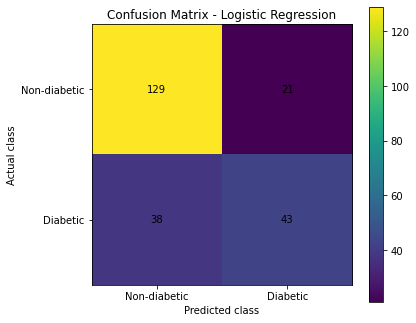

In [6]:
# --------------------------------------------------------- 
# 6. CONFUSION MATRIX AND PERFORMANCE MEASURES 
# --------------------------------------------------------- 
cm = confusion_matrix(y_test, y_pred) 
tn, fp, fn, tp = cm.ravel() 
  
accuracy = accuracy_score(y_test, y_pred) 
true_positive_rate = tp / (tp + fn)       # Sensitivity / Recall 
true_negative_rate = tn / (tn + fp)       # Specificity 
  
print("\nCONFUSION MATRIX") 
print(cm) 
  
print("\nCONFUSION MATRIX VALUES") 
print("True Negative  (TN):", tn) 
print("False Positive (FP):", fp) 
print("False Negative (FN):", fn) 
print("True Positive  (TP):", tp) 
  
performance_table = pd.DataFrame({ 
    "Measure": [ 
        "Accuracy", 
        "True positive rate (Sensitivity/Recall)", 
        "True negative rate (Specificity)" 
    ], 
    "Value": [ 
        accuracy, 
        true_positive_rate, 
        true_negative_rate 
    ] 
}) 
performance_table["Percentage"] = (performance_table["Value"] * 100).round(2) 
  
print("\nPERFORMANCE TABLE") 
print(performance_table.to_string(index=False)) 
  
print("\nCLASSIFICATION REPORT") 
print(classification_report( 
    y_test, 
    y_pred, 
    target_names=["Non-diabetic (0)", "Diabetic (1)"] 
)) 
  
plt.figure(figsize=(6, 5)) 
plt.imshow(cm) 
plt.title("Confusion Matrix - Logistic Regression") 
plt.xlabel("Predicted class") 
plt.ylabel("Actual class") 
plt.xticks([0, 1], ["Non-diabetic", "Diabetic"]) 
plt.yticks([0, 1], ["Non-diabetic", "Diabetic"]) 
  
for i in range(cm.shape[0]): 
    for j in range(cm.shape[1]): 
        plt.text(j, i, str(cm[i, j]), ha="center", va="center") 
  
plt.colorbar() 
plt.tight_layout() 
plt.savefig("confusion_matrix_heatmap.png", dpi=200) 
plt.show() 





ROC-AUC: 0.8362


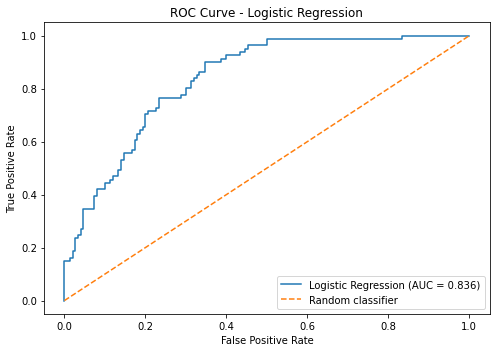

In [7]:
# --------------------------------------------------------- 
# 7. ROC CURVE AND AUC 
# --------------------------------------------------------- 
fpr, tpr, thresholds = roc_curve(y_test, y_probability) 
auc_value = roc_auc_score(y_test, y_probability) 
  
print("\nROC-AUC:", round(auc_value, 4)) 
  
plt.figure(figsize=(7, 5)) 
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_value:.3f})") 
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier") 
plt.xlabel("False Positive Rate") 
plt.ylabel("True Positive Rate") 
plt.title("ROC Curve - Logistic Regression") 
plt.legend() 
plt.tight_layout() 
plt.savefig("roc_curve.png", dpi=200) 
plt.show() 

